In [37]:
# Import modules
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *
from hamiltonians3nu import *
from oscprob3nu import *

import numpy as np 
import matplotlib.pyplot as plt
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import scipy.integrate as integrate
from scipy.integrate import simpson, quad
from scipy.interpolate import interp1d
import copy as cp
import builtins
import itertools
import scipy.linalg as la
from scipy.linalg import expm
import cmath
from scipy.stats import chisquare, ks_2samp, pearsonr
from scipy.stats import wasserstein_distance
from scipy.stats import entropy
from scipy.spatial.distance import cdist

In [26]:
def gaus(data, amplitude, mean, sigma):
    return amplitude * math.e**((-0.5 * (data - mean)**2) / sigma**2)

def fluctuated_fit(gaus, bin_centers, counts):
    popt, _ = curve_fit(gaus, bin_centers, counts)
    return popt

In [27]:
# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])

# Event counts for muon neutrino beam, muon-to-muon
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])
adjusted_counts_fd = np.array([ 0.  ,  7.5 ,  1.  ,  3.  ,  1.  ,  2.  ,  2.  ,  4.  ,  6.  ,
        9.  , 15.  , 12.  , 39.5 , 25.  , 19.25, 20.25, 16.  , 14.  ,
       18.  ])
adjusted_counts_nd = np.array([ 37500., 105000.,  72000.,  96000., 120000., 148000., 170000.,
       192000., 208000., 214000., 212000., 204000., 425000., 280000.,
       181500.,  81000.,  80000.,  25000.,  10000.])

# Event counts for electron neutrio beam, muon-to-electron
counts_nd_e = np.array([0.01, 0.5, 2.4, 4.6, 4, 2.6, 1.8 ,1.4, 1.2])
adjusted_counts_nd_e = np.array([10, 500, 2400, 4600, 400, 2600, 1800, 1400, 1200])
counts_fd_e = np.array([5 ,21, 18, 4, 1, 1])
bin_centers_e = np.array([0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25])
bin_edges_e = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5])

length_nd = 1 # [km]
length_fd = 810 # [km]

bin_widths = bin_edges[1:] - bin_edges[:-1]

# Event counts for antineutrino beam
anti_counts_nd = np.array([2.5, 20, 38.75, 45 ,67.5, 70, 85, 97.5, 107.5, 113.75, 115, 111.25, 95, 62.5, 37.5, 20, 10, 2.5, 0])
anti_counts_fd = np.array([0.25, 2, 1, 2, 0, 2, 3, 0, 0, 8, 3, 7, 4.4, 6, 2.4, 2, 2.4, 1.25, 1.75])
anti_counts_nd_e = np.array([0, 0.25, 1.3, 2.5, 2.52, 1.9, 1.35, 1.15, 0.95]) # The High CNN one, cause it might be better?
anti_counts_fd_e = np.array([1, 8, 5, 3, 1, 1])

adjusted_anti_counts_nd_e = np.array([0, 250, 1300, 2500, 2520, 1900, 1350, 1150, 950])
adjusted_anti_counts_nd = anti_counts_nd * (bin_widths / 0.1) * 1000
adjusted_anti_counts_fd = anti_counts_fd * (bin_widths / 0.1)

print(adjusted_anti_counts_fd)

initial_guess = [140, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess)
print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")


popt_nd_e, _ = curve_fit(gaus, bin_centers_e, counts_nd_e, p0=[5,2, 0.5])
print(f"Fitted parameters for observed the unoscillated ND electon events: Amplitude = {popt_nd_e[0]}, Mean = {popt_nd_e[1]}, Sigma = {popt_nd_e[2]}")

popt_anti_nd, _ = curve_fit(gaus, bin_centers, anti_counts_nd, p0=[120,2,0.5])
print(f"Fitted parameters for observed the unoscillated antineutrino ND events: Amplitude = {popt_anti_nd[0]}, Mean = {popt_anti_nd[1]}, Sigma = {popt_anti_nd[2]}")


popt_anti_nd_e, _ = curve_fit(gaus, bin_centers_e, anti_counts_nd_e, p0=[5,2,0.5])
print(f"Fitted parameters for observed the unoscillated antineutrino ND electron events: Amplitude = {popt_anti_nd_e[0]}, Mean = {popt_anti_nd_e[1]}, Sigma = {popt_anti_nd_e[2]}")

x = np.arange(0.01,5,0.01)

[ 1.875  5.     1.     2.     0.     2.     3.     0.     0.     8.
  3.     7.    11.    15.     6.6    4.5   12.     6.25  17.5  ]
Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692701207105, Mean = 1.8044188236034169, Sigma = 0.525448417032163
Fitted parameters for observed the unoscillated ND electon events: Amplitude = 4.218662147714044, Mean = 2.1341687610051183, Sigma = 0.8475810459857663
Fitted parameters for observed the unoscillated antineutrino ND events: Amplitude = 113.1060196955553, Mean = 1.8355298839724858, Sigma = 0.5285564990530245
Fitted parameters for observed the unoscillated antineutrino ND electron events: Amplitude = 2.4344413635605364, Mean = 2.356842604598921, Sigma = 0.9997075655274238


In [28]:

def osc_prob_2nu_fd(mixing_angle_23, delta_mass_squared_23):

    mixing_angle_12 = math.sqrt(0.307)
    delta_mass_squared_12 = 7.53e-5

    energy = x*1e9
    length_scaled_nd = length_nd * CONV_KM_TO_INV_EV
    length_scaled_fd = length_fd * CONV_KM_TO_INV_EV

    cases = ['vacuum', 'matter']
    types = ['neutrino', 'antineutrino']
    sectors = {'12': (mixing_angle_12, delta_mass_squared_12, {'me': 2, 'mm': 3}),
               '23': (mixing_angle_23, delta_mass_squared_23, {'mm': 0, 'mt': 1})}
    index = sectors.get(sector)
    
    all_counts = {}

    for case in cases:
        for particle_type in types:
            h_mm_nd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_12, delta_mass_squared_12)
            h_me_nd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_12, delta_mass_squared_12)
            h_me_fd = h_me_nd

            h_mm_fd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_23, delta_mass_squared_23)
            h_mt_fd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_23, delta_mass_squared_23)

            if case == 'vacuum':
                def calculate_hamiltonian(h, e):
                    return h / e
            elif case == 'matter':
                def calculate_hamiltonian(h,e):
                    return hamiltonian_2nu_matter(h, e, VCC_EARTH_CRUST)
                
            prob_mm_nd = [probabilities_2nu(calculate_hamiltonian(h_mm_nd, e), length_scaled_nd)[3]
                        for e in energy]
            prob_me_nd = [probabilities_2nu(calculate_hamiltonian(h_me_nd, e), length_scaled_nd)[2]
                        for e in energy]
            prob_me_fd = [probabilities_2nu(calculate_hamiltonian(h_me_fd, e), length_scaled_fd)[2]
                        for e in energy]
            
            prob_mm_fd = [probabilities_2nu(calculate_hamiltonian(h_mm_fd, e), length_scaled_fd)[0]
                        for e in energy]
            prob_mt_fd = [probabilities_2nu(calculate_hamiltonian(h_mt_fd, e), length_scaled_nd)[1]
                        for e in energy]
            
            if particle_type == 'neutrino':
                    popt2 = popt_nd_e
                    bin_edge2 = bin_edges_e
                    popt1 = popt_nd
                    bin_edge1 = bin_edges
            elif particle_type == 'antineutrino':
                    popt1 = popt_anti_nd_e
                    bin_edge2 = bin_edges_e
                    popt2 = popt_anti_nd
                    bin_edge1 = bin_edges

            osc_prob_mm_nd = prob_mm_nd * gaus(x, *popt1)
            gf_mm_nd = interp1d(x, osc_prob_mm_nd, fill_value=0, bounds_error=False)
            
            osc_prob_me_nd = prob_me_nd * gaus(x, *popt2)
            gf_me_nd = interp1d(x, osc_prob_me_nd, fill_value=0, bounds_error=False)

            osc_prob_me_fd = prob_me_fd * gaus(x, *popt2)
            gf_me_fd = interp1d(x, osc_prob_me_fd, fill_value=0, bounds_error=False)

            osc_prob_mm_fd = prob_mm_fd * gaus(x, *popt1)
            gf_mm_fd = interp1d(x, osc_prob_mm_fd, fill_value=0, bounds_error=False)

            osc_prob_mt_fd = prob_mt_fd * gaus(x, *popt1)
            gf_mt_fd = interp1d(x, osc_prob_mt_fd, fill_value=0, bounds_error=False)

            areas1 = []
            areas2 = []
            areas3 = []
            areas4 = []
            areas5 = []

            for i in range(len(bin_edge1) - 1):
                a, b = bin_edge1[i], bin_edge1[i + 1]
                area1, _ = quad(gf_mm_nd, a, b)
                areas1.append(area1)

                area2, _ = quad(gf_mm_fd, a, b)
                areas2.append(area2)

                area3, _ = quad(gf_mt_fd, a, b)
                areas3.append(area3)

            for i in range(len(bin_edge2) - 1):
                a, b = bin_edge2[i], bin_edge2[i + 1]
                area4, _ = quad(gf_me_nd, a, b)
                areas4.append(area4)

                area5, _ = quad(gf_me_fd, a, b)
                areas5.append(area5)

            bin_widths1 = np.diff(bin_edge1)
            bin_widths2 = np.diff(bin_edge2)

            if particle_type == 'neutrino':
                counts1 = (areas1 / bin_widths1)
                counts2 = (areas2 / bin_widths1) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))
                counts3 = (areas3 / bin_widths1) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))

                counts4 = (areas4 / bin_widths2)
                counts5 = (areas4 / bin_widths2) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(osc_prob_me_nd) / np.sum(osc_prob_me_fd)))
                
            elif particle_type == 'antineutrino':
                counts1 = (areas1 / bin_widths1)
                counts2 = (areas2 / bin_widths1) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))
                counts3 = (areas3 / bin_widths1) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(osc_prob_mm_nd) / np.sum(osc_prob_mm_fd))

                counts4 = (areas4 / bin_widths2)
                counts5 = (areas4 / bin_widths2) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(osc_prob_me_nd) / np.sum(osc_prob_me_fd)))

            all_counts[(particle_type, case)] = (counts1, counts2, counts3, counts4, counts5)

    return all_counts



In [29]:
def osc_prob_2nu_fd2(mixing_angle_23, delta_mass_squared_32):
    mixing_angle_12 = np.sqrt(0.307)
    delta_mass_squared_12 = 7.53e-5

    energy = x * 1e9  # Convert to eV
    length_scaled_nd = length_nd * CONV_KM_TO_INV_EV
    length_scaled_fd = length_fd * CONV_KM_TO_INV_EV

    cases = ['vacuum', 'matter']
    types = ['neutrino', 'antineutrino']

    # Precompute Hamiltonians (energy-independent)
    h_mm_nd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_12, delta_mass_squared_12)
    h_me_nd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_12, delta_mass_squared_12)
    h_me_fd = h_me_nd

    h_mm_fd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_23, delta_mass_squared_32)
    h_mt_fd = hamiltonian_2nu_vacuum_energy_independent(mixing_angle_23, delta_mass_squared_32)

    # Store results
    all_counts = {}

    for case in cases:
        for particle_type in types:
            if case == 'vacuum':
                def calculate_hamiltonian(h, e): return h / e
            else:  # matter case
                def calculate_hamiltonian(h, e): return hamiltonian_2nu_matter(h, e, VCC_EARTH_CRUST)

            # Compute probabilities using vectorized NumPy operations
            prob_nd = np.array([
                probabilities_2nu(calculate_hamiltonian(h_mm_nd, e), length_scaled_nd)
                for e in energy
            ])
            prob_nd_e = np.array([
                probabilities_2nu(calculate_hamiltonian(h_me_nd, e), length_scaled_fd)
                for e in energy
            ])
            prob_fd = np.array([
                probabilities_2nu(calculate_hamiltonian(h_mm_fd, e), length_scaled_fd)
                for e in energy
            ])

            prob_me_nd, prob_mm_nd = prob_nd[:, 2], prob_nd[:, 3]
            prob_mm_fd, prob_mt_fd = prob_fd[:, 0], prob_fd[:, 1]
            prob_me_fd = prob_nd_e[:,2]

            # Select Gaussian parameters
            if particle_type == 'neutrino':
                popt_me, bin_edges_me = popt_nd_e, bin_edges_e
                popt_mm, bin_edges_mm = popt_nd, bin_edges
            else:  # antineutrino
                popt_me, bin_edges_me = popt_anti_nd_e, bin_edges_e
                popt_mm, bin_edges_mm = popt_anti_nd, bin_edges

            # Compute Gaussian fits
            gaus_me_nd = prob_me_nd * gaus(x, *popt_me)
            gaus_me_fd = prob_me_fd * gaus(x, *popt_me)
            gaus_mm_nd = prob_mm_nd * gaus(x, *popt_mm)
            gaus_mm_fd = prob_mm_fd * gaus(x, *popt_mm)
            gaus_mt_fd = prob_mt_fd * gaus(x, *popt_mm)

            # Interpolation functions
            gf_me_nd, gf_me_fd = interp1d(x, gaus_me_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_me_fd, fill_value=0, bounds_error=False)
            gf_mm_nd, gf_mm_fd = interp1d(x, gaus_mm_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_mm_fd, fill_value=0, bounds_error=False)
            gf_mt_fd = interp1d(x, gaus_mt_fd, fill_value=0, bounds_error=False)

            # Compute areas via integration
            areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
            areas_mm_fd = np.array([quad(gf_mm_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
            areas_mt_fd = np.array([quad(gf_mt_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])

            areas_me_nd = np.array([quad(gf_me_nd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
            areas_me_fd = np.array([quad(gf_me_fd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])

            bin_widths_mm = np.diff(bin_edges_mm)
            bin_widths_me = np.diff(bin_edges_me)

            # Compute counts
            if particle_type == 'neutrino':
                counts_mm_nd = areas_mm_nd / bin_widths_mm
                counts_mm_fd = (areas_mm_fd / bin_widths_mm) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))
                counts_mt_fd = (areas_mt_fd / bin_widths_mm) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))

                counts_me_nd = areas_me_nd / bin_widths_me
                counts_me_fd = (areas_me_fd / bin_widths_me) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))
                
            else:  # antineutrino
                counts_mm_nd = areas_mm_nd / bin_widths_mm
                counts_mm_fd = (areas_mm_fd / bin_widths_mm) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))
                counts_mt_fd = (areas_mt_fd / bin_widths_mm) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))

                counts_me_nd = areas_me_nd / bin_widths_me
                counts_me_fd = (areas_me_fd / bin_widths_me) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))

            # Store results
            all_counts[(particle_type, case)] = (counts_mm_nd, counts_mm_fd, counts_mt_fd, counts_me_nd, counts_me_fd)

    return all_counts

mixing_angle_23 = np.sqrt(0.57)
delta_mass_squared_32 = 2.e-3
results2 = osc_prob_2nu_fd2(mixing_angle_23, delta_mass_squared_32)
counts_mm_nd, counts_mm_fd, counts_mt_fd, counts_me_nd, counts_me_fd = results2[('neutrino', 'vacuum')]
counts_mm_nd_anti, counts_mm_fd_anti, counts_mt_fd_anti, counts_me_nd_anti, counts_me_fd_anti = results2[('antineutrino', 'matter')]
print(np.sum(counts_mm_fd))

C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C

114.8253983038037


C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:71: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mt_fd = np.array([quad(gf_mt_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])


107.6


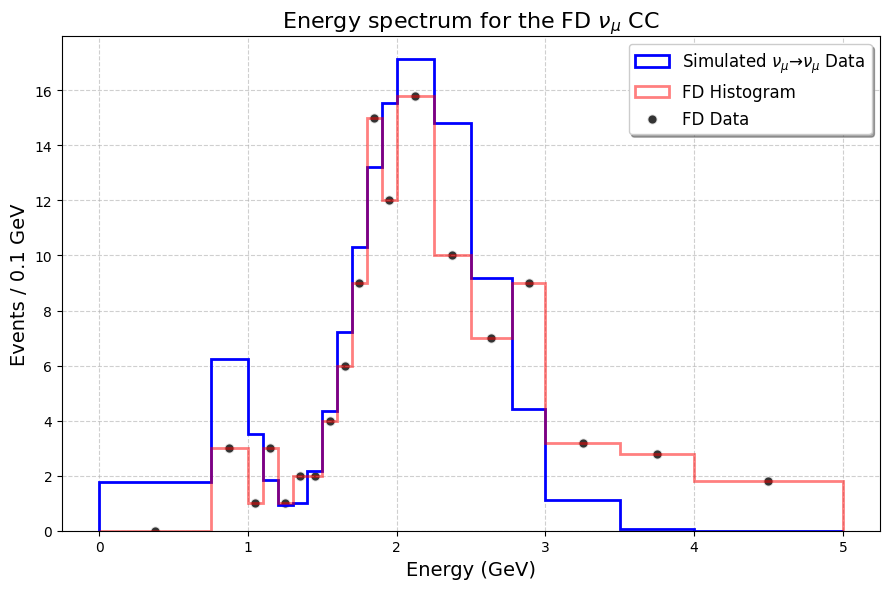

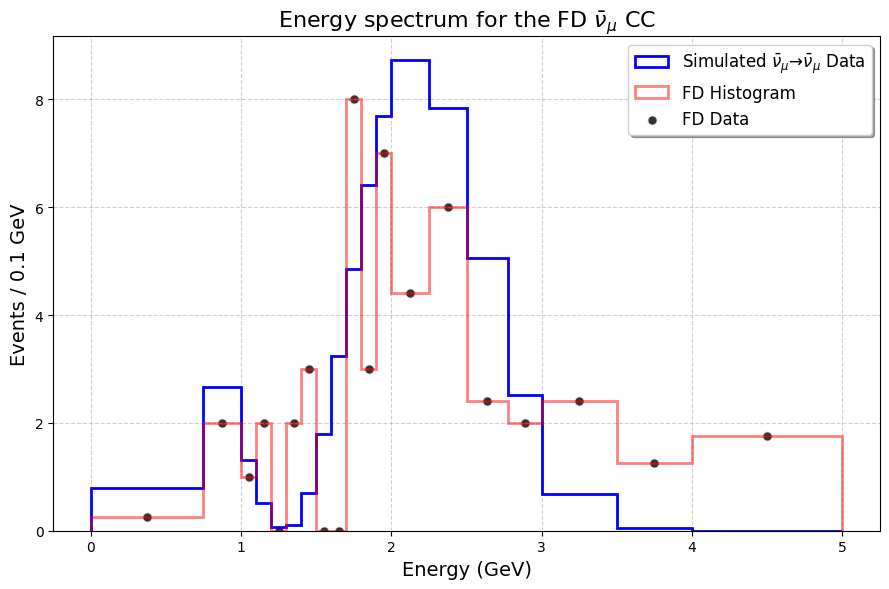

In [30]:
print(np.sum(counts_fd))
plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_mm_fd, histtype='step', label=r'Simulated $\nu _\mu \to \nu _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\nu _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_mm_fd_anti, histtype='step', label=r'Simulated $\bar{\nu} _\mu \to \bar{\nu} _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=anti_counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, anti_counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\bar{\nu} _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [31]:
def best_fit_params_mm_fd(counts_fd, anti_counts_fd):
    # Define the ranges for mixing_angle_23 and delta_mass_squared_32
    mixing_angle_23_range = [np.sqrt(0.57)]#np.linspace(0.4, 0.9, 15)  
    delta_mass_squared_32_range = np.linspace(1.5e-3, 2.7e-3, 36)  
    
    # Initialise variables to track the best parameters found
    best_params = None
    min_diff = float('inf')
    min_diff_anti = float('inf')
    iteration = 0  
    
    for angle in mixing_angle_23_range:
        for delta in delta_mass_squared_32_range:
            # Call osc_prob_2nu_fd2 to get the results for current parameters
            results = osc_prob_2nu_fd2(angle, delta)
            iteration +=1
            
            # Extract counts for neutrinos and antineutrinos in vacuum and matter
            _, counts_mm_fd, _, _, _ = results[('neutrino', 'vacuum')]
            _, counts_mm_fd_anti, _, _, _ = results[('antineutrino', 'matter')]
            
            # Calculate sums of counts_mm_fd and counts_mm_fd_anti
            sum_counts_mm_fd = np.sum(counts_mm_fd)
            sum_counts_mm_fd_anti = np.sum(counts_mm_fd_anti)
            
            # Calculate the difference from the target counts_fd and anti_counts_fd
            diff_neutrino = np.abs(sum_counts_mm_fd - np.sum(counts_fd))
            diff_antineutrino = np.abs(sum_counts_mm_fd_anti - np.sum(anti_counts_fd))
            
            # Check if this parameter set is better (closer to the target sums)
            if diff_neutrino < min_diff:
                min_diff = diff_neutrino
                print(f'Iteration {iteration} for neutrino')
                best_params = (angle, delta)
            if diff_antineutrino < min_diff_anti:
                min_diff_anti = diff_antineutrino
                print(f'Iteration {iteration}  for antineutrino')
                best_params_anti = (angle, delta)
    
    return best_params, best_params_anti

best_params, best_params_anti = best_fit_params_mm_fd(counts_fd, anti_counts_fd)
print("Best parameters for neutrinos (mixing_angle_23, delta_mass_squared_32):", best_params)
print("Best parameters for antineutrinos (mixing_angle_23, delta_mass_squared_32):", best_params_anti)

C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C

Iteration 1 for neutrino
Iteration 1  for antineutrino


C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:70: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mm_fd = np.array([quad(gf_mm_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])


Iteration 2 for neutrino
Iteration 2  for antineutrino
Iteration 3 for neutrino
Iteration 3  for antineutrino
Iteration 4 for neutrino
Iteration 4  for antineutrino


C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:71: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mt_fd = np.array([quad(gf_mt_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])


Iteration 5 for neutrino
Iteration 5  for antineutrino
Iteration 6 for neutrino
Iteration 6  for antineutrino
Iteration 7 for neutrino
Iteration 7  for antineutrino
Iteration 8 for neutrino
Iteration 8  for antineutrino
Iteration 9 for neutrino
Iteration 9  for antineutrino
Iteration 10 for neutrino
Iteration 10  for antineutrino
Iteration 11 for neutrino
Iteration 11  for antineutrino
Iteration 12 for neutrino
Iteration 12  for antineutrino
Iteration 13 for neutrino
Iteration 13  for antineutrino
Iteration 14 for neutrino
Iteration 14  for antineutrino
Iteration 15 for neutrino
Iteration 15  for antineutrino
Iteration 16 for neutrino
Iteration 16  for antineutrino
Iteration 17 for neutrino
Iteration 17  for antineutrino
Iteration 18 for neutrino
Iteration 18  for antineutrino
Iteration 19 for neutrino
Iteration 19  for antineutrino
Iteration 20 for neutrino
Iteration 20  for antineutrino
Iteration 21 for neutrino
Iteration 21  for antineutrino
Iteration 22  for antineutrino
Best param

Try 1:
- Best parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7035714285714286, 0.002172413793103448)
- Best parameters for antineutrinos (mixing_angle_23, delta_mass_squared_32): (0.75, 0.002241379310344828)


Try 2:
- Best parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7214285714285714, 0.0021857142857142856)
- Best parameters for antineutrinos (mixing_angle_23, delta_mass_squared_32): (0.7571428571428571, 0.0022542857142857143)

Try 3:
- Best parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0021857142857142856)
- Best parameters for antineutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.00222)

Try 4:
- Best overall parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0019615384615384616)
- Best EMD parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0021538461538461538)
- Best CHI2 parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0019615384615384616)
- Best KL_D parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0019615384615384616)

C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C

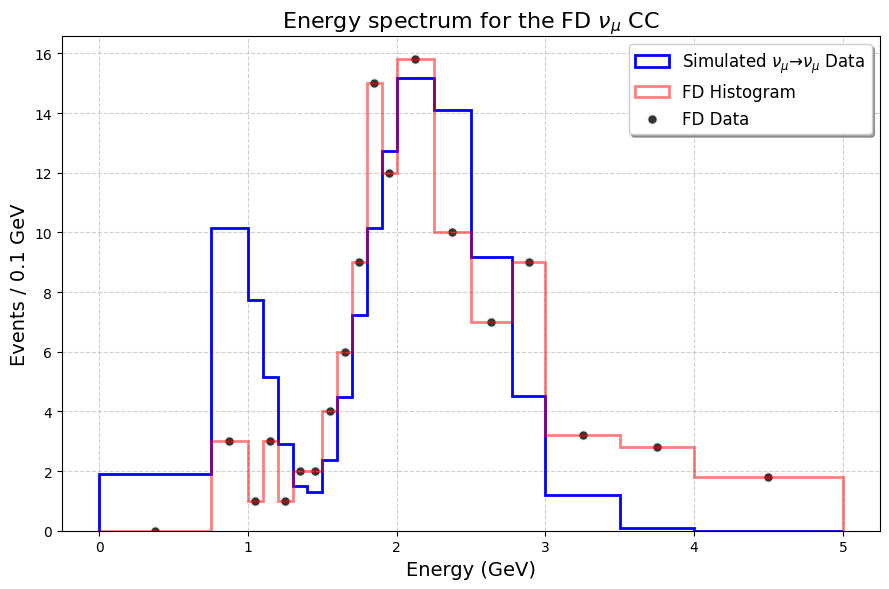

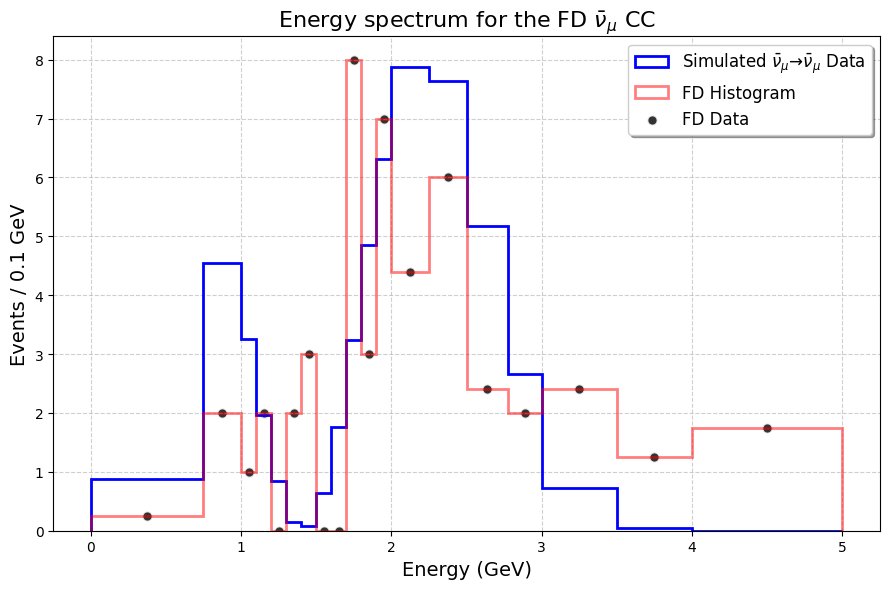

In [32]:
results3 = osc_prob_2nu_fd2(0.7571428571428571, 0.0021857142857142856)
_, counts_mm_fd2, _, _, _ = results3[('neutrino', 'vacuum')]
_, counts_mm_fd_anti2, _, _, _ = results3[('antineutrino', 'matter')]

plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_mm_fd2, histtype='step', label=r'Simulated $\nu _\mu \to \nu _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\nu _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_mm_fd_anti2, histtype='step', label=r'Simulated $\bar{\nu} _\mu \to \bar{\nu} _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=anti_counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, anti_counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\bar{\nu} _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [39]:
def best_fit_params_mm_fd2(counts_fd, anti_counts_fd):
    # Define the parameter space to search over
    mixing_angle_23_range = [np.sqrt(0.57)]  # Adjust as needed
    delta_mass_squared_32_range = np.linspace(1.5e-3, 3e-3, 40)  # Adjust as needed
    
    best_params_emd = None
    best_fit_score_emd = float('inf')  # Lower is better
    best_params_chi2 = None
    best_fit_score_chi2 = float('inf')
    best_params_kld = None
    best_fit_score_kld = float('inf')
    best_params = None
    best_fit_score = float('inf')
    
    for angle in mixing_angle_23_range:
        for delta in delta_mass_squared_32_range:
            # Generate model counts with these parameters
            results = osc_prob_2nu_fd2(angle, delta)
            _, counts_mm_fd, _, _, _ = results[('neutrino', 'vacuum')]
            _, counts_mm_fd_anti, _, _, _ = results[('antineutrino', 'matter')]

            # earth mover's distance: https://en.wikipedia.org/wiki/Earth_mover%27s_distance
            emd = wasserstein_distance(counts_fd, counts_mm_fd)

            # Chi-squared Distance
            epsilon = 1e-15
            chi_squared = np.sum(((counts_fd - counts_mm_fd) ** 2) / (counts_fd + counts_mm_fd + epsilon))

            # Kullback-Leibler Divergence (KL Divergence)
            hist1_norm = counts_fd / counts_fd.sum()
            hist2_norm = counts_mm_fd / counts_mm_fd.sum()
            kl_divergence = entropy(hist1_norm, hist2_norm)

            average_distance = np.mean([emd, chi_squared, kl_divergence])

            # Track best params
            if average_distance < best_fit_score:
                best_fit_score = average_distance
                best_params = (angle, delta)
            
            if emd < best_fit_score_emd:
                best_fit_score_emd = emd
                best_params_emd = (angle, delta)
            
            if chi_squared < best_fit_score_chi2:
                best_fit_score_chi2 = chi_squared
                best_params_chi2 = (angle, delta)
            
            if kl_divergence < best_fit_score_kld:
                best_fit_score_kld = kl_divergence
                best_params_kld = (angle, delta)

    return best_params, best_params_emd, best_params_chi2, best_params_kld

best_params2, best_params_emd, best_params_chi2, best_params_kld  = best_fit_params_mm_fd2(counts_fd, anti_counts_fd)
print("Best overall parameters for neutrinos (mixing_angle_23, delta_mass_squared_32):", best_params2)
print("Best EMD parameters for neutrinos (mixing_angle_23, delta_mass_squared_32):", best_params_emd)
print("Best CHI2 parameters for neutrinos (mixing_angle_23, delta_mass_squared_32):", best_params_chi2)
print("Best KL_D parameters for neutrinos (mixing_angle_23, delta_mass_squared_32):", best_params_kld)

C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C

Best overall parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0019615384615384616)
Best EMD parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0021538461538461538)
Best CHI2 parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0019615384615384616)
Best KL_D parameters for neutrinos (mixing_angle_23, delta_mass_squared_32): (0.7549834435270749, 0.0019615384615384616)


C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C

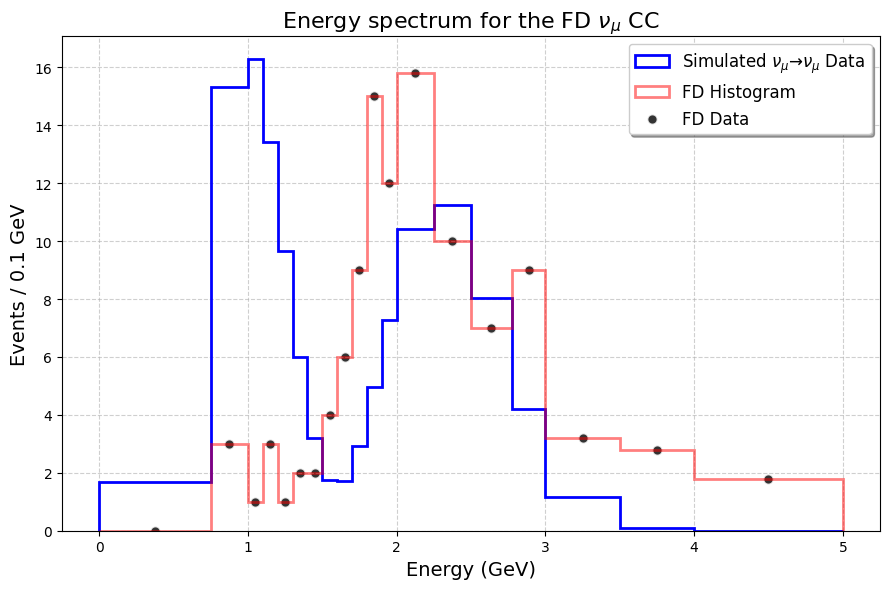

In [34]:
results4 = osc_prob_2nu_fd2(0.7549834435270749, 0.0024615384615384616)
_, counts_mm_fd4, _, _, _ = results4[('neutrino', 'vacuum')]

plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_mm_fd4, histtype='step', label=r'Simulated $\nu _\mu \to \nu _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\nu _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [35]:
print(counts_fd)
print(counts_mm_fd4)

[ 0.   3.   1.   3.   1.   2.   2.   4.   6.   9.  15.  12.  15.8 10.
  7.   9.   3.2  2.8  1.8]
[1.69543029e+00 1.53137908e+01 1.62735034e+01 1.34219425e+01
 9.66041134e+00 5.99543810e+00 3.20438469e+00 1.74255656e+00
 1.71755609e+00 2.92750566e+00 4.95130549e+00 7.26850262e+00
 1.04266816e+01 1.12518564e+01 8.01852695e+00 4.19892508e+00
 1.15490867e+00 7.88386697e-02 1.07040457e-03]


C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C:\Users\Raees\AppData\Local\Temp\ipykernel_30656\2583629113.py:69: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
C

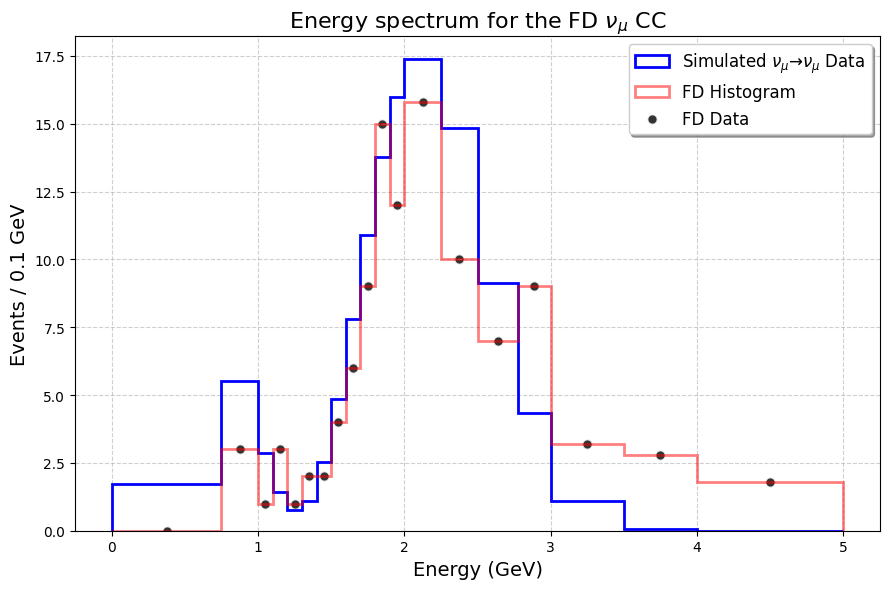

In [40]:
results5 = osc_prob_2nu_fd2(0.7549834435270749, 0.0019615384615384616)
_, counts_mm_fd5, _, _, _ = results5[('neutrino', 'vacuum')]

plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=counts_mm_fd5, histtype='step', label=r'Simulated $\nu _\mu \to \nu _\mu$ Data', linewidth=2, color='b')
plt.hist(bin_edges[:-1], bin_edges,weights=counts_fd, density=False, alpha=0.5, histtype='step', color='r', label='FD Histogram', linewidth=2)
plt.scatter(bin_centers, counts_fd, color='black', label='FD Data' ,edgecolor='white', s=50, alpha=0.8, marker='o', linewidth=1.2 )
plt.title(r'Energy spectrum for the FD $\nu _\mu$ CC', fontsize=16)
plt.ylabel('Events / 0.1 GeV', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()